# Astro Hologram preprocessing

This notebook is the current unified entry point. It reuses completed plate solving, Gaia matching, and StarNet2 outputs by default, then rebuilds the nebula-depth and Three.js export assets. Set a rebuild flag to `True` when that stage needs to run again.

In [1]:
from pathlib import Path
import os

import matplotlib.pyplot as plt
from dotenv import load_dotenv

from catalog import build_catalog
from nebula import luminosity2depth
from scene_export import export_star_scene, load_scene_config
from starnet2 import extract_layers

load_dotenv()
name = 'demo02'
src_img = 'test.PNG'

INPUT_IMAGE = Path(f'data/{name}/{src_img}')
SOLVED_FITS = Path(f'data/{name}/test_solved.fits')
MATCHES_PATH = Path(f'data/{name}/matches.parquet')
STARNET_DIR = Path(f'data/{name}/starnet2')
EXPORT_DIR = Path(f'data/{name}/export')
SCENE_CONFIG_PATH = EXPORT_DIR / 'scene_config.json'

REBUILD_PLATESOLVE = False
REBUILD_CATALOG = False
REBUILD_STARNET2 = False
STARNET_EXE = None  # PATH / STARNET2_PATH / known J:\\StarNet2 install
NEBULA_WHITE_PERCENTILE = 99.5


In [2]:
catalog_result = build_catalog(
    INPUT_IMAGE,
    SOLVED_FITS,
    MATCHES_PATH,
    astrometry_api_key=os.environ.get('ASTROMETRY_API_KEY'),
    reuse_solved=not REBUILD_PLATESOLVE,
    reuse_matches=not (REBUILD_PLATESOLVE or REBUILD_CATALOG),
)
print(f'Solved FITS: {catalog_result.solved_fits_path}')
print(f'Catalog: {len(catalog_result.matches):,} sources -> {catalog_result.matches_path}')

Solved FITS: data\demo02\test_solved.fits
Catalog: 5,146 sources -> data\demo02\matches.parquet


In [3]:
nebula_fits = STARNET_DIR / f'{SOLVED_FITS.stem}_nebula.fits'
stars_fits = STARNET_DIR / f'{SOLVED_FITS.stem}_stars.fits'

if REBUILD_STARNET2 or not (nebula_fits.is_file() and stars_fits.is_file()):
    extraction = extract_layers(
        SOLVED_FITS,
        STARNET_DIR,
        executable=STARNET_EXE,
        output_suffix='.fits',
        overwrite=REBUILD_STARNET2,
    )
    nebula_fits, stars_fits = extraction.nebula_path, extraction.stars_path

print(f'Nebula layer: {nebula_fits}')
print(f'Star layer:   {stars_fits}')

Nebula layer: data\demo02\starnet2\test_solved_nebula.fits
Star layer:   data\demo02\starnet2\test_solved_stars.fits


In [4]:
scene_config = load_scene_config(SCENE_CONFIG_PATH)
nebula_result = luminosity2depth(
    nebula_fits,
    EXPORT_DIR,
    background_distance_pc=scene_config['bg_dist_pc'],
    background_z=scene_config['bg_z_scene'],
    depth_coefficient=scene_config['depth_coeff'],
    default_transform=scene_config.get('nebula_transform', 'linear'),
    color_white_percentile=NEBULA_WHITE_PERCENTILE,
)
print(f'Nebula pixels: {nebula_result.nebula_mask.sum():,}')
print(f'Depth scale:  {nebula_result.nebula_depth_scale:.6f}')
print(f'Signal:       {nebula_result.signal_path}')

Nebula pixels: 2,038,818
Depth scale:  -849.066685
Signal:       data\demo02\export\nebula_signal.png


In [5]:
star_export = export_star_scene(
    catalog_result.matches,
    stars_fits,
    EXPORT_DIR,
    solved_fits_path=SOLVED_FITS,
    scene_config_path=SCENE_CONFIG_PATH,
)
print(f'Exported stars: {len(star_export.star_records):,}')
print(f'Atlas:          {star_export.atlas_path}')
print(f'Scene data:     {star_export.stars_path}')
print(f'Gaia catalog:   {star_export.catalog_path}')

Exported stars: 1,155
Atlas:          data\demo02\export\stars_atlas.png
Scene data:     data\demo02\export\stars.json
Gaia catalog:   data\demo02\export\star_catalog.json


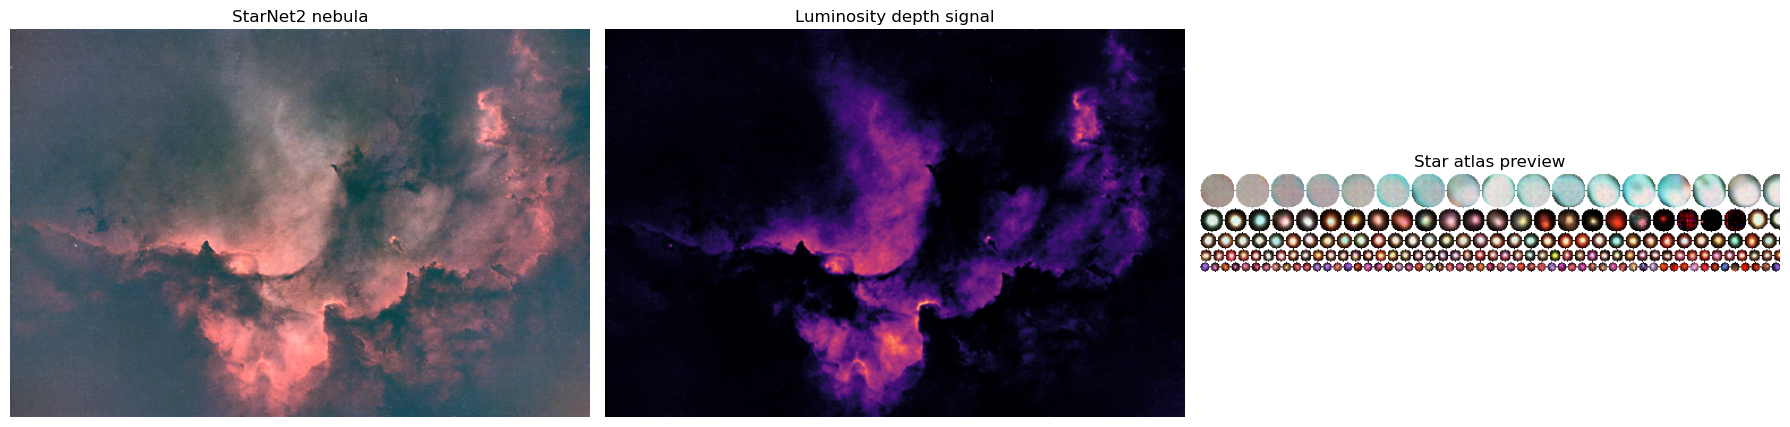

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(nebula_result.color_rgb, origin='upper')
axes[0].set_title('StarNet2 nebula')
axes[1].imshow(nebula_result.signal, origin='upper', cmap='magma', vmin=0, vmax=1)
axes[1].set_title('Luminosity depth signal')
axes[2].imshow(star_export.atlas[:512, :512], origin='upper')
axes[2].set_title('Star atlas preview')
for axis in axes:
    axis.axis('off')
plt.tight_layout()
plt.show()